# Feature Engineering

# 1. Data Loading

In [11]:
from pathlib import Path
import hashlib
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
PROJECT_ROOT = Path.cwd().resolve()

EXPORT_BASE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "macro_regime_v2"
)

LATEST_PATH = EXPORT_BASE / "latest.json"

if not LATEST_PATH.exists():
    raise FileNotFoundError(
        "No compiled data snapshot found. "
        "Run Data_Engineering.ipynb first."
    )

latest_pointer = json.loads(
    LATEST_PATH.read_text(encoding="utf-8")
)

SNAPSHOT_DIR = (
    EXPORT_BASE
    / latest_pointer["snapshot_id"]
)

MANIFEST_PATH = SNAPSHOT_DIR / "manifest.json"

manifest = json.loads(
    MANIFEST_PATH.read_text(encoding="utf-8")
)


def file_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    digest = hashlib.sha256()

    with file_path.open("rb") as file:
        while chunk := file.read(chunk_size):
            digest.update(chunk)

    return digest.hexdigest()


def load_artifact(
    name: str,
    verify_hash: bool = True,
) -> pd.DataFrame:
    if name not in manifest["artifacts"]:
        raise KeyError(
            f"Artifact not found in manifest: {name}"
        )

    metadata = manifest["artifacts"][name]
    file_path = SNAPSHOT_DIR / metadata["file"]

    if not file_path.exists():
        raise FileNotFoundError(file_path)

    if verify_hash:
        actual_hash = file_sha256(file_path)

        if actual_hash != metadata["sha256"]:
            raise ValueError(
                f"Checksum failure for {name}"
            )

    frame = pd.read_parquet(file_path)

    expected_shape = (
        metadata["rows"],
        metadata["columns"],
    )

    if frame.shape != expected_shape:
        raise ValueError(
            f"{name}: expected {expected_shape}, "
            f"received {frame.shape}"
        )

    return frame


compiled_macro_events = load_artifact(
    "compiled_macro_events"
)

weekly_macro_raw = load_artifact(
    "weekly_macro_raw"
)

weekly_macro_compiled = load_artifact(
    "weekly_macro_compiled"
)

weekly_macro_observation_dates = load_artifact(
    "weekly_macro_observation_dates"
)

weekly_macro_available_dates = load_artifact(
    "weekly_macro_available_dates"
)

weekly_macro_observation_age_days = load_artifact(
    "weekly_macro_observation_age_days"
)

weekly_macro_publication_age_days = load_artifact(
    "weekly_macro_publication_age_days"
)

weekly_macro_stale = load_artifact(
    "weekly_macro_stale"
).astype(bool)

weekly_market_compiled = load_artifact(
    "weekly_market_compiled"
)

weekly_target_prices = load_artifact(
    "weekly_target_prices"
)

decision_calendar = load_artifact(
    "decision_calendar"
)

dataset_contracts = load_artifact(
    "dataset_contracts"
)

macro_staleness_limits = load_artifact(
    "macro_staleness_limits"
).iloc[:, 0]

compiled_coverage = load_artifact(
    "compiled_coverage"
)

sample_audit = load_artifact(
    "sample_audit"
)


compiled_samples = {}

for sample_name, sample_metadata in manifest[
    "samples"
].items():
    compiled_samples[sample_name] = {
        "name": sample_name,
        "start": pd.Timestamp(sample_metadata["start"]),
        "end": pd.Timestamp(sample_metadata["end"]),
        "inputs": load_artifact(
            f"sample_{sample_name}_inputs"
        ),
        "targets": load_artifact(
            f"sample_{sample_name}_targets"
        ),
        "calendar": load_artifact(
            f"sample_{sample_name}_calendar"
        ),
        "valid_week": load_artifact(
            f"sample_{sample_name}_valid_week"
        )["valid_week"].astype(bool),
        "required_series": sample_metadata[
            "required_series"
        ],
    }


core_panel = compiled_samples["core"]["inputs"]
core_target_prices = compiled_samples["core"]["targets"]
core_calendar = compiled_samples["core"]["calendar"]
core_valid_week = compiled_samples["core"]["valid_week"]

assert core_panel.index.equals(core_target_prices.index)
assert core_panel.index.equals(core_valid_week.index)

print(
    f"Loaded snapshot {manifest['snapshot_id']} | "
    f"core panel {core_panel.shape[0]:,} × "
    f"{core_panel.shape[1]:,}"
)

display(sample_audit)
display(core_panel.tail())

Loaded snapshot as_of_2026-09-10 | core panel 656 × 18


,start,end,calendar_weeks,input_series,required_series,valid_weeks,valid_week_pct,longest_invalid_run_weeks,target_complete_weeks
sample,,,,,,,,,
core,2014-02-14,2026-09-04,656,18,8,649,98.932927,6,656
funding_2018,2018-04-06,2026-09-04,440,22,12,434,98.636364,6,440
realtime_2019,2019-09-06,2026-09-04,366,20,10,360,98.360656,6,366
reserves_2021,2021-07-30,2026-09-04,267,19,9,261,97.752809,6,267
credit_2023,2023-09-15,2026-09-04,156,19,9,150,96.153846,6,156


,INDPRO,ICSA,unrate,cleveland_cpi_nowcast_mom,cleveland_core_cpi_nowcast_mom,cpi_index_sa,T10YIE,infl_5y5y,NFCI,ANFCI,fedfunds,DFII10,massive_treasury_yield_3_month,massive_treasury_yield_2_year,massive_treasury_yield_10_year,EPU,oil_wti,VIX
decision_date,,,,,,,,,,,,,,,,,,
2026-08-07,102.6395,199000.0,4.1,0.377373,0.203008,332.568,2.25,2.28,-0.529,-0.543,3.63,2.43,3.87,4.19,4.65,173.93,81.96,14.90
2026-08-14,102.6395,209000.0,4.1,0.345617,0.203342,332.813,2.27,2.30,-0.549,-0.579,3.63,2.39,3.86,4.17,4.68,219.75,84.77,14.25
2026-08-21,102.9939,206000.0,4.1,0.347334,0.203342,332.813,2.34,2.34,-0.559,-0.587,3.63,2.35,3.88,4.24,4.74,301.86,86.48,15.13
2026-08-28,102.9939,203000.0,4.1,0.355918,0.203342,332.813,2.31,2.32,-0.566,-0.576,3.63,2.34,3.90,4.34,4.73,131.19,83.90,14.43
2026-09-04,102.9939,206000.0,4.1,0.382154,0.194477,332.813,2.35,2.33,-0.558,-0.582,3.63,2.42,3.91,4.37,4.78,205.69,91.48,14.53


# 2. Core Features

## 2.1 Growth

In [4]:
# ============================================================
# Growth features: point-in-time snapshot utilities
# ============================================================

CORE_INDEX = compiled_samples["core"]["inputs"].index

INDPRO_STALENESS_DAYS = 90
ICSA_STALENESS_DAYS = 14


def prepare_versioned_series(
    events: pd.DataFrame,
    series: str,
) -> pd.DataFrame:
    frame = events.loc[
        events["series"].eq(series),
        [
            "observation_date",
            "available_date",
            "valid_to",
            "value",
        ],
    ].copy()

    if frame.empty:
        raise KeyError(f"No canonical events for {series}.")

    for column in [
        "observation_date",
        "available_date",
        "valid_to",
    ]:
        frame[column] = pd.to_datetime(
            frame[column],
            errors="raise",
        )

    return frame.sort_values(
        [
            "observation_date",
            "available_date",
        ]
    ).reset_index(drop=True)


def active_snapshot(
    events: pd.DataFrame,
    decision_date: pd.Timestamp,
) -> pd.DataFrame:
    decision_date = pd.Timestamp(decision_date)

    active = events.loc[
        events["available_date"].le(decision_date)
        & events["valid_to"].ge(decision_date)
        & events["observation_date"].le(decision_date)
    ].copy()

    if active.duplicated("observation_date").any():
        raise ValueError(
            f"Overlapping vintages at {decision_date.date()}."
        )

    return (
        active.set_index("observation_date")
        .sort_index()
    )


indpro_versioned = prepare_versioned_series(
    compiled_macro_events,
    "INDPRO",
)

icsa_versioned = prepare_versioned_series(
    compiled_macro_events,
    "ICSA",
)

In [5]:
# ============================================================
# PIT INDPRO growth
# ============================================================

def build_indpro_growth(
    events: pd.DataFrame,
    decision_index: pd.DatetimeIndex,
) -> pd.DataFrame:
    records = []

    for decision_date in decision_index:
        snapshot = active_snapshot(
            events,
            decision_date,
        )

        record = {
            "decision_date": decision_date,
            "indpro_latest_observation_date": pd.NaT,
            "indpro_source_available_date": pd.NaT,
            "indpro_observation_age_days": np.nan,
            "indpro_publication_age_days": np.nan,
            "indpro_level": np.nan,
            "indpro_3m_ann": np.nan,
            "indpro_yoy": np.nan,
            "indpro_acceleration": np.nan,
        }

        if snapshot.empty:
            records.append(record)
            continue

        latest_date = snapshot.index.max()
        lag_3m_date = latest_date - pd.DateOffset(months=3)
        lag_12m_date = latest_date - pd.DateOffset(months=12)

        required_dates = [
            latest_date,
            lag_3m_date,
            lag_12m_date,
        ]

        if not all(
            date in snapshot.index
            for date in required_dates
        ):
            records.append(record)
            continue

        required = snapshot.loc[required_dates]

        if required["value"].isna().any():
            records.append(record)
            continue

        current_level = float(
            required.loc[latest_date, "value"]
        )
        lag_3m_level = float(
            required.loc[lag_3m_date, "value"]
        )
        lag_12m_level = float(
            required.loc[lag_12m_date, "value"]
        )

        if min(
            current_level,
            lag_3m_level,
            lag_12m_level,
        ) <= 0:
            raise ValueError(
                "INDPRO contains a nonpositive level."
            )

        source_available_date = required[
            "available_date"
        ].max()

        publication_age = (
            decision_date - source_available_date
        ).days

        growth_3m = (
            400
            * np.log(
                current_level / lag_3m_level
            )
        )

        growth_yoy = (
            100
            * np.log(
                current_level / lag_12m_level
            )
        )

        record.update(
            {
                "indpro_latest_observation_date": (
                    latest_date
                ),
                "indpro_source_available_date": (
                    source_available_date
                ),
                "indpro_observation_age_days": (
                    decision_date - latest_date
                ).days,
                "indpro_publication_age_days": (
                    publication_age
                ),
                "indpro_level": current_level,
                "indpro_3m_ann": growth_3m,
                "indpro_yoy": growth_yoy,
                "indpro_acceleration": (
                    growth_3m - growth_yoy
                ),
            }
        )

        records.append(record)

    result = (
        pd.DataFrame(records)
        .set_index("decision_date")
        .sort_index()
    )

    stale = result[
        "indpro_publication_age_days"
    ].gt(INDPRO_STALENESS_DAYS)

    growth_columns = [
        "indpro_level",
        "indpro_3m_ann",
        "indpro_yoy",
        "indpro_acceleration",
    ]

    result.loc[stale, growth_columns] = np.nan
    result["indpro_stale"] = stale

    return result


indpro_growth = build_indpro_growth(
    indpro_versioned,
    CORE_INDEX,
)

In [7]:
# ============================================================
# PIT initial-claims signal
# ============================================================

def build_claims_growth_overlay(
    events: pd.DataFrame,
    decision_index: pd.DatetimeIndex,
) -> pd.DataFrame:
    records = []

    for decision_date in decision_index:
        snapshot = active_snapshot(
            events,
            decision_date,
        )

        record = {
            "decision_date": decision_date,
            "icsa_latest_observation_date": pd.NaT,
            "icsa_source_available_date": pd.NaT,
            "icsa_publication_age_days": np.nan,
            "icsa_ma4": np.nan,
            "icsa_ma4_lag4": np.nan,
            "icsa_ma4_lag13": np.nan,
            "claims_strength_4w": np.nan,
            "claims_strength_13w": np.nan,
        }

        if len(snapshot) < 17:
            records.append(record)
            continue

        recent = snapshot.iloc[-17:].copy()

        expected_span = pd.Timedelta(
            weeks=16
        )

        if (
            recent.index[-1] - recent.index[0]
            != expected_span
        ):
            records.append(record)
            continue

        if recent["value"].isna().any():
            records.append(record)
            continue

        current_window = recent.iloc[-4:]
        lag_4_window = recent.iloc[-8:-4]
        lag_13_window = recent.iloc[-17:-13]

        current_ma4 = current_window["value"].mean()
        lag_4_ma4 = lag_4_window["value"].mean()
        lag_13_ma4 = lag_13_window["value"].mean()

        if min(
            current_ma4,
            lag_4_ma4,
            lag_13_ma4,
        ) <= 0:
            raise ValueError(
                "ICSA contains a nonpositive moving average."
            )

        input_rows = pd.concat(
            [
                current_window,
                lag_4_window,
                lag_13_window,
            ]
        )

        source_available_date = input_rows[
            "available_date"
        ].max()

        publication_age = (
            decision_date - source_available_date
        ).days

        record.update(
            {
                "icsa_latest_observation_date": (
                    recent.index[-1]
                ),
                "icsa_source_available_date": (
                    source_available_date
                ),
                "icsa_publication_age_days": (
                    publication_age
                ),
                "icsa_ma4": current_ma4,
                "icsa_ma4_lag4": lag_4_ma4,
                "icsa_ma4_lag13": lag_13_ma4,
                "claims_strength_4w": (
                    -100
                    * np.log(
                        current_ma4 / lag_4_ma4
                    )
                ),
                "claims_strength_13w": (
                    -100
                    * np.log(
                        current_ma4 / lag_13_ma4
                    )
                ),
            }
        )

        records.append(record)

    result = (
        pd.DataFrame(records)
        .set_index("decision_date")
        .sort_index()
    )

    stale = result[
        "icsa_publication_age_days"
    ].gt(ICSA_STALENESS_DAYS)

    feature_columns = [
        "icsa_ma4",
        "icsa_ma4_lag4",
        "icsa_ma4_lag13",
        "claims_strength_4w",
        "claims_strength_13w",
    ]

    result.loc[stale, feature_columns] = np.nan
    result["icsa_stale"] = stale

    return result


claims_growth = build_claims_growth_overlay(
    icsa_versioned,
    CORE_INDEX,
)

In [8]:
# ============================================================
# Causal expanding normalization
# ============================================================

NORMALIZATION_WARMUP_WEEKS = 104
NUMERICAL_Z_CAP = 5.0


def causal_expanding_zscore(
    series: pd.Series,
    min_periods: int = NORMALIZATION_WARMUP_WEEKS,
) -> pd.DataFrame:
    expanding = series.expanding(
        min_periods=min_periods
    )

    historical_mean = (
        expanding.mean().shift(1)
    )

    historical_std = (
        expanding.std(ddof=1).shift(1)
    )

    valid_std = historical_std.gt(0)

    z_uncapped = (
        (series - historical_mean)
        / historical_std.where(valid_std)
    )

    return pd.DataFrame(
        {
            "raw": series,
            "expanding_mean": historical_mean,
            "expanding_std": historical_std,
            "z_uncapped": z_uncapped,
            "z_capped": z_uncapped.clip(
                -NUMERICAL_Z_CAP,
                NUMERICAL_Z_CAP,
            ),
        }
    )


growth_scalers = {
    "indpro_3m_ann": causal_expanding_zscore(
        indpro_growth["indpro_3m_ann"]
    ),
    "indpro_yoy": causal_expanding_zscore(
        indpro_growth["indpro_yoy"]
    ),
    "claims_strength_4w": causal_expanding_zscore(
        claims_growth["claims_strength_4w"]
    ),
    "claims_strength_13w": causal_expanding_zscore(
        claims_growth["claims_strength_13w"]
    ),
}


growth_features = pd.DataFrame(
    index=CORE_INDEX
)

growth_features["indpro_3m_ann"] = (
    indpro_growth["indpro_3m_ann"]
)

growth_features["indpro_yoy"] = (
    indpro_growth["indpro_yoy"]
)

growth_features["indpro_acceleration"] = (
    indpro_growth["indpro_acceleration"]
)

growth_features["z_indpro_3m_ann_uncapped"] = (
    growth_scalers["indpro_3m_ann"]["z_uncapped"]
)

growth_features["z_indpro_yoy_uncapped"] = (
    growth_scalers["indpro_yoy"]["z_uncapped"]
)

growth_features["z_indpro_3m_ann"] = (
    growth_scalers["indpro_3m_ann"]["z_capped"]
)

growth_features["z_indpro_yoy"] = (
    growth_scalers["indpro_yoy"]["z_capped"]
)

growth_features["claims_strength_4w"] = (
    claims_growth["claims_strength_4w"]
)

growth_features["claims_strength_13w"] = (
    claims_growth["claims_strength_13w"]
)

growth_features["z_claims_strength_4w"] = (
    growth_scalers["claims_strength_4w"]["z_capped"]
)

growth_features["z_claims_strength_13w"] = (
    growth_scalers["claims_strength_13w"]["z_capped"]
)


core_components = growth_features[
    [
        "z_indpro_3m_ann",
        "z_indpro_yoy",
    ]
]

both_core_components_available = (
    core_components.notna().all(axis=1)
)

growth_features["growth_score_core"] = (
    0.5 * core_components["z_indpro_3m_ann"]
    + 0.5 * core_components["z_indpro_yoy"]
).where(both_core_components_available)


uncapped_components = growth_features[
    [
        "z_indpro_3m_ann_uncapped",
        "z_indpro_yoy_uncapped",
    ]
]

growth_features["growth_score_uncapped"] = (
    0.5
    * uncapped_components[
        "z_indpro_3m_ann_uncapped"
    ]
    + 0.5
    * uncapped_components[
        "z_indpro_yoy_uncapped"
    ]
).where(
    uncapped_components.notna().all(axis=1)
)

In [9]:
# ============================================================
# Growth-feature lineage and hard assertions
# ============================================================

growth_feature_lineage = pd.concat(
    [
        indpro_growth[
            [
                "indpro_latest_observation_date",
                "indpro_source_available_date",
                "indpro_observation_age_days",
                "indpro_publication_age_days",
                "indpro_stale",
            ]
        ],
        claims_growth[
            [
                "icsa_latest_observation_date",
                "icsa_source_available_date",
                "icsa_publication_age_days",
                "icsa_stale",
            ]
        ],
    ],
    axis=1,
)

valid_indpro_lineage = growth_feature_lineage[
    "indpro_source_available_date"
].notna()

assert growth_feature_lineage.loc[
    valid_indpro_lineage,
    "indpro_source_available_date",
].le(
    growth_feature_lineage.index[
        valid_indpro_lineage
    ]
).all()

assert growth_feature_lineage.loc[
    valid_indpro_lineage,
    "indpro_latest_observation_date",
].le(
    growth_feature_lineage.index[
        valid_indpro_lineage
    ]
).all()


valid_claims_lineage = growth_feature_lineage[
    "icsa_source_available_date"
].notna()

assert growth_feature_lineage.loc[
    valid_claims_lineage,
    "icsa_source_available_date",
].le(
    growth_feature_lineage.index[
        valid_claims_lineage
    ]
).all()

assert growth_feature_lineage.loc[
    valid_claims_lineage,
    "icsa_latest_observation_date",
].le(
    growth_feature_lineage.index[
        valid_claims_lineage
    ]
).all()

assert (
    growth_feature_lineage[
        "indpro_publication_age_days"
    ]
    .dropna()
    .ge(0)
    .all()
)

assert (
    growth_feature_lineage[
        "icsa_publication_age_days"
    ]
    .dropna()
    .ge(0)
    .all()
)

In [10]:
# ============================================================
# Growth-feature coverage and distribution
# ============================================================

GROWTH_DIAGNOSTIC_COLUMNS = [
    "indpro_3m_ann",
    "indpro_yoy",
    "indpro_acceleration",
    "claims_strength_4w",
    "claims_strength_13w",
    "z_indpro_3m_ann",
    "z_indpro_yoy",
    "z_claims_strength_4w",
    "z_claims_strength_13w",
    "growth_score_core",
]

growth_feature_audit = pd.DataFrame(
    {
        "observations": (
            growth_features[
                GROWTH_DIAGNOSTIC_COLUMNS
            ].notna().sum()
        ),
        "coverage_pct": (
            100
            * growth_features[
                GROWTH_DIAGNOSTIC_COLUMNS
            ].notna().mean()
        ),
        "first_valid_week": (
            growth_features[
                GROWTH_DIAGNOSTIC_COLUMNS
            ].apply(
                lambda series: (
                    series.first_valid_index()
                )
            )
        ),
        "mean": growth_features[
            GROWTH_DIAGNOSTIC_COLUMNS
        ].mean(),
        "std": growth_features[
            GROWTH_DIAGNOSTIC_COLUMNS
        ].std(),
        "minimum": growth_features[
            GROWTH_DIAGNOSTIC_COLUMNS
        ].min(),
        "maximum": growth_features[
            GROWTH_DIAGNOSTIC_COLUMNS
        ].max(),
    }
)

growth_correlation = growth_features[
    [
        "indpro_3m_ann",
        "indpro_yoy",
        "claims_strength_4w",
        "claims_strength_13w",
        "growth_score_core",
    ]
].corr(
    method="spearman",
    min_periods=52,
)

display(growth_feature_audit)
display(growth_correlation)
display(growth_features.tail())

,observations,coverage_pct,first_valid_week,mean,std,minimum,maximum
indpro_3m_ann,603,91.920732,2015-02-20,1.189161,10.682324,-66.760091,39.185141
indpro_yoy,603,91.920732,2015-02-20,1.022074,4.057684,-16.567051,16.202678
indpro_acceleration,603,91.920732,2015-02-20,0.167087,9.619264,-50.193040,47.232289
claims_strength_4w,649,98.932927,2014-02-14,0.327381,23.803835,-316.515741,65.887204
claims_strength_13w,649,98.932927,2014-02-14,0.908479,43.051171,-329.380834,144.850696
z_indpro_3m_ann,499,76.067073,2017-02-17,0.147540,1.148771,-5.000000,3.101669
z_indpro_yoy,499,76.067073,2017-02-17,0.134531,1.257836,-5.000000,3.655486
z_claims_strength_4w,545,83.079268,2016-02-12,0.005913,0.915944,-5.000000,3.693290
z_claims_strength_13w,545,83.079268,2016-02-12,-0.073574,1.081511,-5.000000,3.095452
growth_score_core,499,76.067073,2017-02-17,0.141035,1.074184,-5.000000,2.414183


,indpro_3m_ann,indpro_yoy,claims_strength_4w,claims_strength_13w,growth_score_core
indpro_3m_ann,1.000000,0.388169,-0.032524,0.125757,0.672717
indpro_yoy,0.388169,1.000000,-0.016121,0.134803,0.803139
claims_strength_4w,-0.032524,-0.016121,1.000000,0.458526,0.014429
claims_strength_13w,0.125757,0.134803,0.458526,1.000000,0.170342
growth_score_core,0.672717,0.803139,0.014429,0.170342,1.000000


,indpro_3m_ann,indpro_yoy,indpro_acceleration,z_indpro_3m_ann_uncapped,z_indpro_yoy_uncapped,z_indpro_3m_ann,z_indpro_yoy,claims_strength_4w,claims_strength_13w,z_claims_strength_4w,z_claims_strength_13w,growth_score_core,growth_score_uncapped
decision_date,,,,,,,,,,,,,
2026-08-07,4.004015,1.137590,2.866425,0.263627,0.028508,0.263627,0.028508,9.816488,2.115823,0.398005,0.028092,0.146068,0.146068
2026-08-14,4.004015,1.137590,2.866425,0.263392,0.028485,0.263392,0.028485,7.616974,2.481517,0.305522,0.036538,0.145938,0.145938
2026-08-21,1.845525,1.073671,0.771854,0.061598,0.012748,0.061598,0.012748,1.941809,-0.614630,0.067394,-0.035242,0.037173,0.037173
2026-08-28,1.845525,1.073671,0.771854,0.061546,0.012737,0.061546,0.012737,-1.100929,1.329325,-0.060290,0.009870,0.037142,0.037142
2026-09-04,1.845525,1.073671,0.771854,0.061495,0.012726,0.061495,0.012726,-4.062097,3.554877,-0.184549,0.061519,0.037111,0.037111


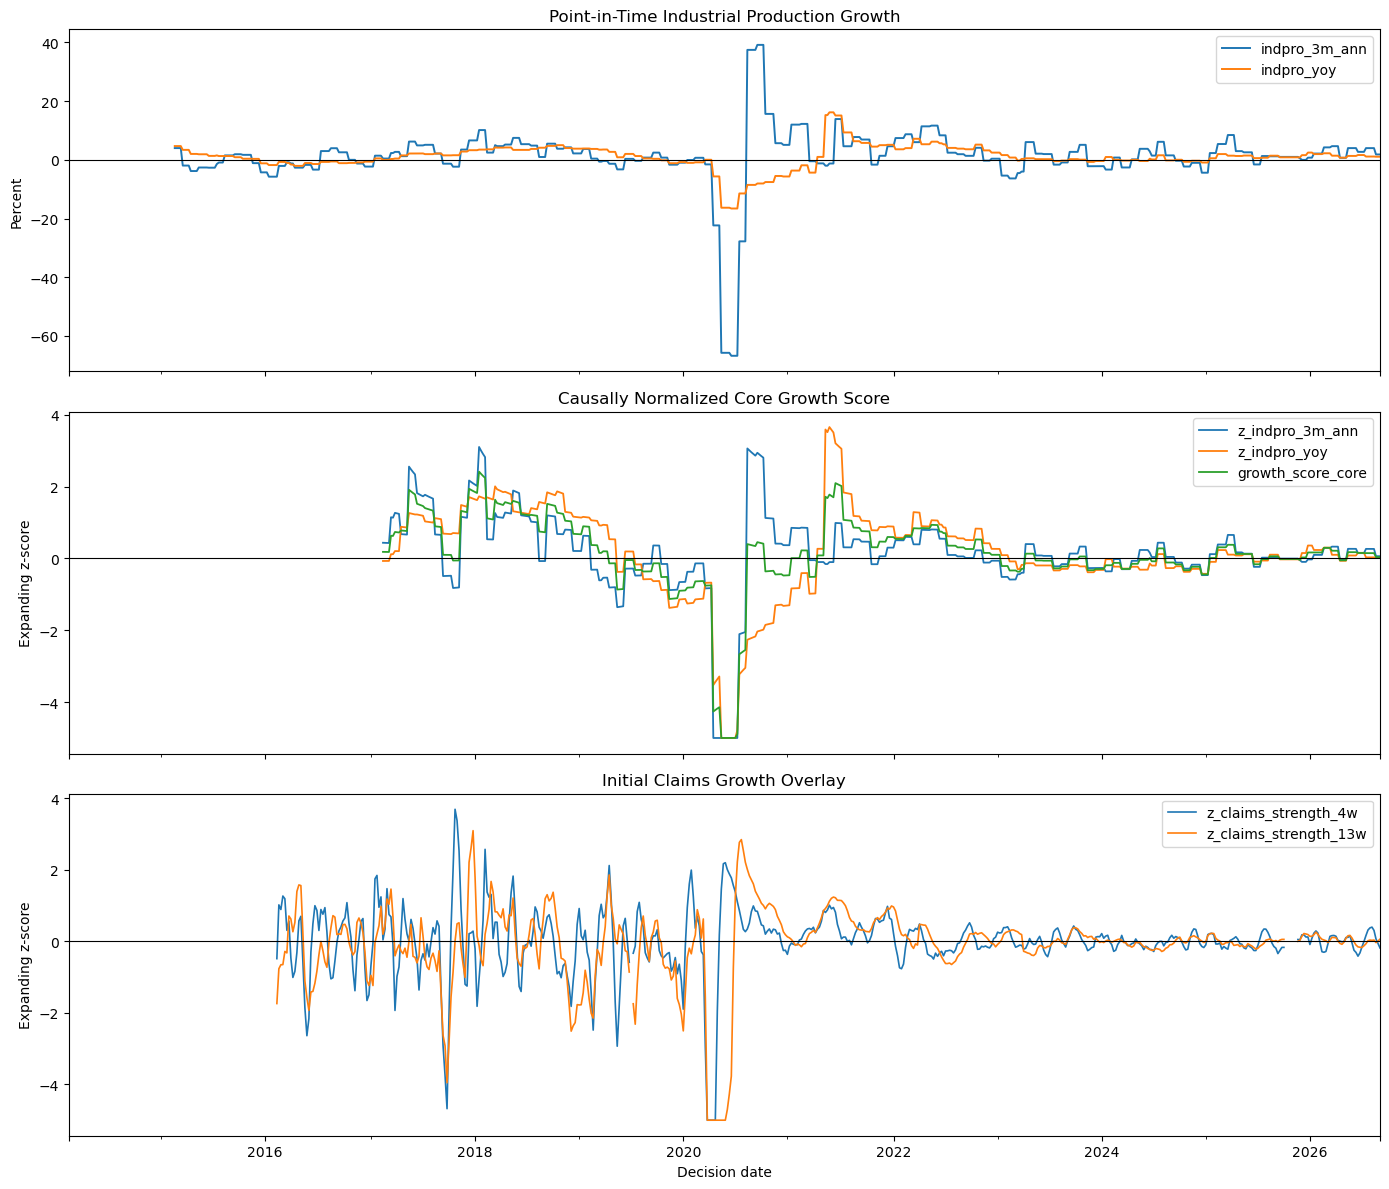

In [12]:
# ============================================================
# Growth-feature plots
# ============================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(14, 12),
    sharex=True,
)

growth_features[
    [
        "indpro_3m_ann",
        "indpro_yoy",
    ]
].plot(
    ax=axes[0],
    linewidth=1.4,
)

axes[0].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[0].set_title(
    "Point-in-Time Industrial Production Growth"
)
axes[0].set_ylabel("Percent")


growth_features[
    [
        "z_indpro_3m_ann",
        "z_indpro_yoy",
        "growth_score_core",
    ]
].plot(
    ax=axes[1],
    linewidth=1.3,
)

axes[1].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[1].set_title(
    "Causally Normalized Core Growth Score"
)
axes[1].set_ylabel("Expanding z-score")


growth_features[
    [
        "z_claims_strength_4w",
        "z_claims_strength_13w",
    ]
].plot(
    ax=axes[2],
    linewidth=1.2,
)

axes[2].axhline(
    0,
    color="black",
    linewidth=0.8,
)

axes[2].set_title(
    "Initial Claims Growth Overlay"
)
axes[2].set_ylabel("Expanding z-score")
axes[2].set_xlabel("Decision date")

plt.tight_layout()
plt.show()

In [13]:
def build_indpro_growth(
    events: pd.DataFrame,
    decision_index: pd.DatetimeIndex,
) -> pd.DataFrame:
    records = []

    for decision_date in decision_index:
        snapshot = active_snapshot(
            events,
            decision_date,
        )

        record = {
            "decision_date": decision_date,
            "indpro_latest_observation_date": pd.NaT,
            "indpro_source_available_date": pd.NaT,
            "indpro_observation_age_days": np.nan,
            "indpro_publication_age_days": np.nan,
            "indpro_level": np.nan,
            "indpro_3m_ann": np.nan,
            "indpro_yoy": np.nan,
            "indpro_acceleration": np.nan,
        }

        if snapshot.empty:
            records.append(record)
            continue

        latest_date = snapshot.index.max()
        current_value = snapshot.loc[latest_date, "value"]

        if not np.isfinite(current_value) or current_value <= 0:
            records.append(record)
            continue

        source_available_date = snapshot.loc[
            latest_date,
            "available_date",
        ]

        record.update(
            {
                "indpro_latest_observation_date": latest_date,
                "indpro_source_available_date": (
                    source_available_date
                ),
                "indpro_observation_age_days": (
                    decision_date - latest_date
                ).days,
                "indpro_publication_age_days": (
                    decision_date - source_available_date
                ).days,
                "indpro_level": float(current_value),
            }
        )

        lag_3m_date = (
            latest_date - pd.DateOffset(months=3)
        )

        if lag_3m_date in snapshot.index:
            lag_3m_value = snapshot.loc[
                lag_3m_date,
                "value",
            ]

            if (
                np.isfinite(lag_3m_value)
                and lag_3m_value > 0
            ):
                record["indpro_3m_ann"] = (
                    400
                    * np.log(
                        current_value / lag_3m_value
                    )
                )

        lag_12m_date = (
            latest_date - pd.DateOffset(months=12)
        )

        if lag_12m_date in snapshot.index:
            lag_12m_value = snapshot.loc[
                lag_12m_date,
                "value",
            ]

            if (
                np.isfinite(lag_12m_value)
                and lag_12m_value > 0
            ):
                record["indpro_yoy"] = (
                    100
                    * np.log(
                        current_value / lag_12m_value
                    )
                )

        if (
            np.isfinite(record["indpro_3m_ann"])
            and np.isfinite(record["indpro_yoy"])
        ):
            record["indpro_acceleration"] = (
                record["indpro_3m_ann"]
                - record["indpro_yoy"]
            )

        records.append(record)

    result = (
        pd.DataFrame(records)
        .set_index("decision_date")
        .sort_index()
    )

    stale = result[
        "indpro_publication_age_days"
    ].gt(INDPRO_STALENESS_DAYS)

    result.loc[
        stale,
        [
            "indpro_level",
            "indpro_3m_ann",
            "indpro_yoy",
            "indpro_acceleration",
        ],
    ] = np.nan

    result["indpro_stale"] = stale

    return result


indpro_growth = build_indpro_growth(
    indpro_versioned,
    CORE_INDEX,
)

In [14]:
# ============================================================
# Test 1: coverage, episode behavior, and extreme observations
# ============================================================

def growth_episode(
    date: pd.Timestamp,
) -> str:
    if date.year < 2020:
        return "Pre-2020"

    if date.year <= 2021:
        return "2020-2021"

    return "2022 onward"


growth_test_data = growth_features.copy()

growth_test_data["episode"] = [
    growth_episode(date)
    for date in growth_test_data.index
]

EPISODE_TEST_COLUMNS = [
    "indpro_3m_ann",
    "indpro_yoy",
    "claims_strength_13w",
    "z_indpro_3m_ann_uncapped",
    "z_indpro_yoy_uncapped",
    "growth_score_uncapped",
    "growth_score_core",
]

growth_episode_statistics = (
    growth_test_data.groupby("episode")[
        EPISODE_TEST_COLUMNS
    ]
    .agg(
        ["count", "mean", "std", "min", "median", "max"]
    )
)

uncapped_tail_mask = (
    growth_features[
        [
            "z_indpro_3m_ann_uncapped",
            "z_indpro_yoy_uncapped",
        ]
    ]
    .abs()
    .gt(NUMERICAL_Z_CAP)
    .any(axis=1)
)

growth_tail_events = pd.concat(
    [
        growth_features.loc[
            uncapped_tail_mask,
            [
                "indpro_3m_ann",
                "indpro_yoy",
                "z_indpro_3m_ann_uncapped",
                "z_indpro_yoy_uncapped",
                "growth_score_uncapped",
                "growth_score_core",
            ],
        ],
        growth_feature_lineage.loc[
            uncapped_tail_mask,
            [
                "indpro_latest_observation_date",
                "indpro_source_available_date",
            ],
        ],
    ],
    axis=1,
)

score_cap_difference = (
    growth_features["growth_score_core"]
    - growth_features["growth_score_uncapped"]
)

growth_tail_summary = pd.Series(
    {
        "weeks_with_component_beyond_5sd": (
            int(uncapped_tail_mask.sum())
        ),
        "share_of_normalized_sample": (
            uncapped_tail_mask.sum()
            / growth_features[
                "growth_score_uncapped"
            ].notna().sum()
        ),
        "maximum_score_cap_difference": (
            score_cap_difference.abs().max()
        ),
        "indpro_stale_weeks": int(
            indpro_growth["indpro_stale"].sum()
        ),
        "claims_stale_weeks": int(
            claims_growth["icsa_stale"].sum()
        ),
    },
    name="Growth tail diagnostics",
)

display(growth_tail_summary)
display(growth_episode_statistics)
display(growth_tail_events)

weeks_with_component_beyond_5sd    13.000000
share_of_normalized_sample          0.026052
maximum_score_cap_difference        6.885895
indpro_stale_weeks                  0.000000
claims_stale_weeks                  6.000000
Name: Growth tail diagnostics, dtype: float64

indpro_3m_ann                                            \
                    count      mean        std        min    median   
episode                                                               
2020-2021             105 -0.788285  24.393393 -66.760091  1.392033   
2022 onward           244  2.025110   3.790284  -6.322417  1.889338   
Pre-2020              254  1.203572   3.290542  -5.725543  1.124443   

                       indpro_yoy                                 ...  \
                   max      count      mean       std        min  ...   
episode                                                           ...   
2020-2021    39.185141        105 -1.216648  8.459677 -16.567051  ...   
2022 onward  11.675484        244  1.492069  1.856024  -0.902818  ...   
Pre-2020     10.156167        254  1.496038  1.982765  -2.048126  ...   

            growth_score_uncapped                                 \
                              std        min    median       max   
episode                                                            
2020-2021                2.485540 -11.885895  0.006739  2.095408   
2022 onward              0.313860  -0.448429  0.037126  0.934109   
Pre-2020                 0.854939  -1.130943  0.769133  2.414183   

            growth_score_core                                          \
                        count      mean       std       min    median   
episode                                                                 
2020-2021                 105 -0.493698  1.847769 -5.000000  0.006739   
2022 onward               244  0.082849  0.313860 -0.448429  0.037126   
Pre-2020                  150  0.679998  0.854939 -1.130943  0.769133   

                       
                  max  
episode                
2020-2021    2.095408  
2022 onward  0.934109  
Pre-2020     2.414183  

[3 rows x 42 columns]

,indpro_3m_ann,indpro_yoy,z_indpro_3m_ann_uncapped,z_indpro_yoy_uncapped,growth_score_uncapped,growth_score_core,indpro_latest_observation_date,indpro_source_available_date
decision_date,,,,,,,,
2020-04-17,-22.330025,-5.642699,-7.275086,-3.526475,-5.400780,-4.263237,2020-03-01,2020-04-15
2020-04-24,-22.330025,-5.642699,-6.637926,-3.441313,-5.039620,-4.220657,2020-03-01,2020-04-15
2020-05-01,-22.330025,-5.642699,-6.143366,-3.362040,-4.752703,-4.181020,2020-03-01,2020-04-15
2020-05-08,-22.330025,-5.642699,-5.745088,-3.288005,-4.516547,-4.144003,2020-03-01,2020-04-15
2020-05-15,-65.748828,-16.304346,-15.591823,-8.179967,-11.885895,-5.000000,2020-04-01,2020-05-15
2020-05-22,-65.748828,-16.304346,-11.319228,-7.317422,-9.318325,-5.000000,2020-04-01,2020-05-15
2020-05-29,-65.748828,-16.304346,-9.326582,-6.680508,-8.003545,-5.000000,2020-04-01,2020-05-15
2020-06-05,-65.748828,-16.304346,-8.114420,-6.185387,-7.149903,-5.000000,2020-04-01,2020-05-15
2020-06-12,-65.748828,-16.304346,-7.278051,-5.786217,-6.532134,-5.000000,2020-04-01,2020-05-15


In [15]:
# ============================================================
# Test 2: ADF and KPSS stationarity
#
# ADF H0: the feature has a unit root.
# KPSS H0: the feature is level-stationary.
# ============================================================

import warnings

from statsmodels.tsa.stattools import adfuller, kpss


def longest_contiguous_weekly_block(
    series: pd.Series,
) -> pd.Series:
    valid = series.dropna().sort_index()

    if valid.empty:
        return valid

    breaks = (
        valid.index.to_series()
        .diff()
        .ne(pd.Timedelta(days=7))
    )

    breaks.iloc[0] = False
    groups = breaks.cumsum()

    group_sizes = valid.groupby(groups).size()
    largest_group = group_sizes.idxmax()

    return valid.loc[
        groups.eq(largest_group).to_numpy()
    ]


def stationarity_test(
    series: pd.Series,
) -> dict:
    block = longest_contiguous_weekly_block(series)

    if len(block) < 40:
        return {
            "n": len(block),
            "start": block.index.min(),
            "end": block.index.max(),
            "adf_stat": np.nan,
            "adf_p": np.nan,
            "kpss_stat": np.nan,
            "kpss_p": np.nan,
            "classification": "Insufficient sample",
        }

    adf_maxlag = min(
        13,
        max(1, len(block) // 10),
    )

    adf_result = adfuller(
        block.to_numpy(),
        maxlag=adf_maxlag,
        regression="c",
        autolag="AIC",
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")

        kpss_result = kpss(
            block.to_numpy(),
            regression="c",
            nlags="auto",
        )

    adf_p = float(adf_result[1])
    kpss_p = float(kpss_result[1])

    if adf_p < 0.05 and kpss_p >= 0.05:
        classification = "Stationary evidence"

    elif adf_p >= 0.05 and kpss_p < 0.05:
        classification = "Nonstationary evidence"

    elif adf_p < 0.05 and kpss_p < 0.05:
        classification = "Regime/break ambiguity"

    else:
        classification = "Low test power/inconclusive"

    return {
        "n": len(block),
        "start": block.index.min(),
        "end": block.index.max(),
        "adf_stat": adf_result[0],
        "adf_lags": adf_result[2],
        "adf_p": adf_p,
        "kpss_stat": kpss_result[0],
        "kpss_lags": kpss_result[2],
        "kpss_p": kpss_p,
        "classification": classification,
    }


STATIONARITY_FEATURES = [
    "indpro_3m_ann",
    "indpro_yoy",
    "growth_score_uncapped",
    "growth_score_core",
    "claims_strength_13w",
]

STATIONARITY_EPISODES = {
    "Full": growth_features.index.to_series().notna(),
    "Pre-2020": growth_features.index.year < 2020,
    "2020-2021": growth_features.index.year.isin(
        [2020, 2021]
    ),
    "2022 onward": growth_features.index.year >= 2022,
}

stationarity_rows = []

for episode_name, episode_mask in (
    STATIONARITY_EPISODES.items()
):
    for feature in STATIONARITY_FEATURES:
        result = stationarity_test(
            growth_features.loc[
                episode_mask,
                feature,
            ]
        )

        stationarity_rows.append(
            {
                "episode": episode_name,
                "feature": feature,
                **result,
            }
        )

growth_stationarity_results = (
    pd.DataFrame(stationarity_rows)
    .set_index(["episode", "feature"])
)

display(growth_stationarity_results)

n      start        end  adf_stat  \
episode     feature                                                      
Full        indpro_3m_ann          603 2015-02-20 2026-09-04 -4.619371   
            indpro_yoy             603 2015-02-20 2026-09-04 -3.287138   
            growth_score_uncapped  499 2017-02-17 2026-09-04 -3.402767   
            growth_score_core      499 2017-02-17 2026-09-04 -2.779143   
            claims_strength_13w    326 2019-07-12 2025-10-03 -2.733300   
Pre-2020    indpro_3m_ann          254 2015-02-20 2019-12-27 -2.239707   
            indpro_yoy             254 2015-02-20 2019-12-27 -1.349076   
            growth_score_uncapped  150 2017-02-17 2019-12-27 -1.469506   
            growth_score_core      150 2017-02-17 2019-12-27 -1.469506   
            claims_strength_13w    281 2014-02-14 2019-06-28 -6.369802   
2020-2021   indpro_3m_ann          105 2020-01-03 2021-12-31 -2.224388   
            indpro_yoy             105 2020-01-03 2021-12-31 -0.988630   
            growth_score_uncapped  105 2020-01-03 2021-12-31 -2.324031   
            growth_score_core      105 2020-01-03 2021-12-31 -2.141050   
            claims_strength_13w    105 2020-01-03 2021-12-31 -3.014609   
2022 onward indpro_3m_ann          244 2022-01-07 2026-09-04 -3.433364   
            indpro_yoy             244 2022-01-07 2026-09-04 -3.082118   
            growth_score_uncapped  244 2022-01-07 2026-09-04 -2.633595   
            growth_score_core      244 2022-01-07 2026-09-04 -2.633595   
            claims_strength_13w    196 2022-01-07 2025-10-03 -4.007977   

                                   adf_lags         adf_p  kpss_stat  \
episode     feature                                                    
Full        indpro_3m_ann                13  1.189567e-04   0.057429   
            indpro_yoy                   13  1.546328e-02   0.087920   
            growth_score_uncapped        13  1.086490e-02   0.241372   
            growth_score_core            13  6.131537e-02   0.325721   
            claims_strength_13w          13  6.845110e-02   0.100242   
Pre-2020    indpro_3m_ann                13  1.921509e-01   0.636548   
            indpro_yoy                   13  6.064318e-01   0.716361   
            growth_score_uncapped         0  5.485388e-01   0.955494   
            growth_score_core             0  5.485388e-01   0.955494   
            claims_strength_13w           9  2.360401e-08   0.141994   
2020-2021   indpro_3m_ann                 9  1.975132e-01   0.290268   
            indpro_yoy                    9  7.573888e-01   0.884318   
            growth_score_uncapped         4  1.643344e-01   0.782082   
            growth_score_core             4  2.283317e-01   0.801530   
            claims_strength_13w           1  3.355248e-02   0.421088   
2022 onward indpro_3m_ann                 0  9.872734e-03   0.295023   
            indpro_yoy                   13  2.790517e-02   0.855799   
            growth_score_uncapped         0  8.625081e-02   0.592031   
            growth_score_core             0  8.625081e-02   0.592031   
            claims_strength_13w           9  1.369311e-03   0.084766   

                                   kpss_lags    kpss_p  \
episode     feature                                      
Full        indpro_3m_ann                 15  0.100000   
            indpro_yoy                    16  0.100000   
            growth_score_uncapped         12  0.100000   
            growth_score_core             12  0.100000   
            claims_strength_13w           10  0.100000   
Pre-2020    indpro_3m_ann                  9  0.019314   
            indpro_yoy                    10  0.012058   
            growth_score_uncapped          8  0.010000   
            growth_score_core              8  0.010000   
            claims_strength_13w            9  0.100000   
2020-2021   indpro_3m_ann                  5  0.100000   
            indpro_yoy                     6  0.010000   
           

In [16]:
# ============================================================
# Test 3: component redundancy
# ============================================================

from scipy import stats


growth_component_sample = growth_features[
    [
        "z_indpro_3m_ann",
        "z_indpro_yoy",
    ]
].dropna()

pearson_correlation = growth_component_sample.corr(
    method="pearson"
).iloc[0, 1]

spearman_correlation = growth_component_sample.corr(
    method="spearman"
).iloc[0, 1]

component_vif = (
    1 / (1 - pearson_correlation**2)
)


def circular_block_correlation_ci(
    data: pd.DataFrame,
    method: str,
    block_weeks: int,
    bootstrap_draws: int = 3_999,
    seed: int = 917,
) -> dict:
    data = data.dropna().copy()

    if data.shape[1] != 2:
        raise ValueError(
            "Correlation bootstrap requires two columns."
        )

    values = data.to_numpy()
    n = len(values)

    if n < 2 * block_weeks:
        raise ValueError(
            "Block length is too large for the sample."
        )

    rng = np.random.default_rng(seed)
    draws = np.empty(bootstrap_draws)

    offsets = np.arange(block_weeks)

    for draw in range(bootstrap_draws):
        starts = rng.integers(
            0,
            n,
            size=int(np.ceil(n / block_weeks)),
        )

        indices = (
            starts[:, None] + offsets
        ) % n

        indices = indices.ravel()[:n]
        sample = values[indices]

        if method == "pearson":
            draws[draw] = np.corrcoef(
                sample[:, 0],
                sample[:, 1],
            )[0, 1]

        elif method == "spearman":
            draws[draw] = stats.spearmanr(
                sample[:, 0],
                sample[:, 1],
            ).statistic

        else:
            raise ValueError(method)

    lower, upper = np.quantile(
        draws,
        [0.025, 0.975],
    )

    return {
        "method": method,
        "block_weeks": block_weeks,
        "observed": (
            pearson_correlation
            if method == "pearson"
            else spearman_correlation
        ),
        "bootstrap_se": draws.std(ddof=1),
        "ci_95_low": lower,
        "ci_95_high": upper,
    }


growth_correlation_bootstrap = pd.DataFrame(
    [
        circular_block_correlation_ci(
            growth_component_sample,
            method=method,
            block_weeks=block,
            seed=917 + block,
        )
        for method in ["pearson", "spearman"]
        for block in [13, 26, 52]
    ]
).set_index(["method", "block_weeks"])

growth_redundancy_summary = pd.Series(
    {
        "pearson_correlation": pearson_correlation,
        "spearman_correlation": spearman_correlation,
        "two_component_vif": component_vif,
    },
    name="Growth component redundancy",
)

display(growth_redundancy_summary)
display(growth_correlation_bootstrap)

pearson_correlation     0.592976
spearman_correlation    0.474924
two_component_vif       1.542308
Name: Growth component redundancy, dtype: float64

observed  bootstrap_se  ci_95_low  ci_95_high
method   block_weeks                                               
pearson  13           0.592976      0.198630   0.085817    0.836585
         26           0.592976      0.184783   0.107427    0.831917
         52           0.592976      0.169234   0.143821    0.834419
spearman 13           0.474924      0.127190   0.203526    0.693756
         26           0.474924      0.143630   0.163723    0.717508
         52           0.474924      0.146420   0.157983    0.717623

In [17]:
# ============================================================
# Test 4 setup: first-release INDPRO forecast panel
# ============================================================

first_release_rows = (
    indpro_versioned.sort_values(
        [
            "observation_date",
            "available_date",
        ]
    )
    .groupby(
        "observation_date",
        as_index=False,
        sort=True,
    )
    .head(1)
)

monthly_test_records = []

for _, first_release in first_release_rows.iterrows():
    target_month = pd.Timestamp(
        first_release["observation_date"]
    )

    target_release = pd.Timestamp(
        first_release["available_date"]
    )

    forecast_origin = (
        target_month + pd.offsets.MonthEnd(1)
    )

    if target_release <= forecast_origin:
        continue

    eligible_decisions = CORE_INDEX[
        CORE_INDEX <= forecast_origin
    ]

    if len(eligible_decisions) == 0:
        continue

    decision_date = eligible_decisions[-1]

    release_snapshot = active_snapshot(
        indpro_versioned,
        target_release,
    )

    previous_month = (
        target_month - pd.DateOffset(months=1)
    )

    if (
        target_month not in release_snapshot.index
        or previous_month not in release_snapshot.index
    ):
        continue

    target_level = release_snapshot.loc[
        target_month,
        "value",
    ]

    target_base = release_snapshot.loc[
        previous_month,
        "value",
    ]

    if (
        not np.isfinite(target_level)
        or not np.isfinite(target_base)
        or min(target_level, target_base) <= 0
    ):
        continue

    known_snapshot = active_snapshot(
        indpro_versioned,
        decision_date,
    )

    if len(known_snapshot) < 2:
        continue

    latest_known_month = known_snapshot.index.max()
    previous_known_month = (
        latest_known_month - pd.DateOffset(months=1)
    )

    if previous_known_month not in known_snapshot.index:
        continue

    known_level = known_snapshot.loc[
        latest_known_month,
        "value",
    ]

    known_base = known_snapshot.loc[
        previous_known_month,
        "value",
    ]

    if (
        not np.isfinite(known_level)
        or not np.isfinite(known_base)
        or min(known_level, known_base) <= 0
    ):
        continue

    monthly_test_records.append(
        {
            "forecast_origin": forecast_origin,
            "decision_date": decision_date,
            "target_month": target_month,
            "target_release": target_release,
            "latest_known_month": latest_known_month,
            "ip_growth_first_1m": (
                100
                * (
                    target_level / target_base
                    - 1
                )
            ),
            "ip_growth_known_1m": (
                100
                * (
                    known_level / known_base
                    - 1
                )
            ),
            "growth_score_core": (
                growth_features.at[
                    decision_date,
                    "growth_score_core",
                ]
            ),
            "z_indpro_3m_ann": (
                growth_features.at[
                    decision_date,
                    "z_indpro_3m_ann",
                ]
            ),
            "z_indpro_yoy": (
                growth_features.at[
                    decision_date,
                    "z_indpro_yoy",
                ]
            ),
            "z_claims_strength_4w": (
                growth_features.at[
                    decision_date,
                    "z_claims_strength_4w",
                ]
            ),
            "z_claims_strength_13w": (
                growth_features.at[
                    decision_date,
                    "z_claims_strength_13w",
                ]
            ),
        }
    )

growth_monthly_test_panel = (
    pd.DataFrame(monthly_test_records)
    .set_index("forecast_origin")
    .sort_index()
)

assert (
    growth_monthly_test_panel["decision_date"]
    <= growth_monthly_test_panel.index
).all()

assert (
    growth_monthly_test_panel.index
    < growth_monthly_test_panel["target_release"]
).all()

print(
    f"{len(growth_monthly_test_panel)} monthly targets | "
    f"{growth_monthly_test_panel.index.min().date()} to "
    f"{growth_monthly_test_panel.index.max().date()}"
)

display(growth_monthly_test_panel.tail())

149 monthly targets | 2014-03-31 to 2026-07-31


,decision_date,target_month,target_release,latest_known_month,ip_growth_first_1m,ip_growth_known_1m,growth_score_core,z_indpro_3m_ann,z_indpro_yoy,z_claims_strength_4w,z_claims_strength_13w
forecast_origin,,,,,,,,,,,
2026-03-31,2026-03-27,2026-03-01,2026-04-16,2026-02-01,-0.541507,0.151080,0.213155,0.326765,0.099546,0.164864,0.105567
2026-04-30,2026-04-24,2026-04-01,2026-05-15,2026-03-01,0.678054,-0.541507,-0.053153,-0.039359,-0.066947,-0.013163,-0.081628
2026-05-31,2026-05-29,2026-05-01,2026-06-15,2026-04-01,0.135110,0.678054,0.172956,0.265800,0.080113,-0.038712,0.093446
2026-06-30,2026-06-26,2026-06-01,2026-07-17,2026-05-01,0.076930,0.135110,0.150585,0.146214,0.154956,-0.320720,-0.164509
2026-07-31,2026-07-31,2026-07-01,2026-08-18,2026-06-01,0.201485,0.076930,0.146197,0.263863,0.028532,0.376524,0.035532


In [18]:
# ============================================================
# Test 4: calendar-aware HAC regressions
# ============================================================

import statsmodels.api as sm

from scipy.stats import chi2, norm


def fit_calendar_hac(
    data: pd.DataFrame,
    dependent: str,
    regressors: list[str],
    hac_months: int = 6,
):
    columns = [dependent, *regressors]

    sample = (
        data[columns]
        .dropna()
        .astype(float)
        .sort_index()
    )

    months = pd.DatetimeIndex(
        sample.index
    ).to_period("M")

    if not months.is_unique:
        raise ValueError(
            "More than one observation per calendar month."
        )

    if regressors:
        X = sm.add_constant(
            sample[regressors],
            has_constant="add",
        )
    else:
        X = pd.DataFrame(
            {"const": 1.0},
            index=sample.index,
        )

    y = sample[dependent]

    x_array = X.to_numpy()
    n, p = x_array.shape

    if n <= p:
        raise ValueError("Insufficient observations.")

    if np.linalg.matrix_rank(x_array) < p:
        raise ValueError("Rank-deficient regression.")

    fit = sm.OLS(y, X).fit()

    month_numbers = months.asi8

    distance = np.abs(
        month_numbers[:, None]
        - month_numbers[None, :]
    )

    weights = np.maximum(
        1
        - distance / (hac_months + 1),
        0,
    )

    scores = (
        x_array
        * np.asarray(fit.resid)[:, None]
    )

    bread = np.asarray(
        fit.normalized_cov_params
    )

    covariance = (
        n / (n - p)
    ) * bread @ (
        scores.T @ weights @ scores
    ) @ bread

    covariance = (
        covariance + covariance.T
    ) / 2

    covariance = pd.DataFrame(
        covariance,
        index=X.columns,
        columns=X.columns,
    )

    standard_errors = pd.Series(
        np.sqrt(np.diag(covariance)),
        index=X.columns,
    )

    z_statistics = (
        fit.params / standard_errors
    )

    table = pd.DataFrame(
        {
            "beta": fit.params,
            "hac_se": standard_errors,
            "z": z_statistics,
            "p_two_sided": (
                2 * norm.sf(
                    np.abs(z_statistics)
                )
            ),
            "p_positive": norm.sf(
                z_statistics
            ),
            "ci_95_low": (
                fit.params
                - norm.ppf(0.975)
                * standard_errors
            ),
            "ci_95_high": (
                fit.params
                + norm.ppf(0.975)
                * standard_errors
            ),
        }
    )

    return sample, fit, covariance, table


def joint_wald_test(
    fit,
    covariance: pd.DataFrame,
    terms: list[str],
) -> dict:
    beta = fit.params.loc[terms].to_numpy()
    sub_covariance = covariance.loc[
        terms,
        terms,
    ].to_numpy()

    statistic = float(
        beta
        @ np.linalg.solve(
            sub_covariance,
            beta,
        )
    )

    return {
        "terms": ", ".join(terms),
        "wald_chi2": statistic,
        "df": len(terms),
        "p_value": chi2.sf(
            statistic,
            len(terms),
        ),
    }


GROWTH_REGRESSION_SPECS = {
    "Score only": [
        "growth_score_core",
    ],
    "Persistence": [
        "ip_growth_known_1m",
    ],
    "Score incremental": [
        "ip_growth_known_1m",
        "growth_score_core",
    ],
    "Components incremental": [
        "ip_growth_known_1m",
        "z_indpro_3m_ann",
        "z_indpro_yoy",
    ],
    "Claims incremental": [
        "ip_growth_known_1m",
        "growth_score_core",
        "z_claims_strength_13w",
    ],
}

growth_hac_fits = {}
growth_hac_rows = []

for specification, regressors in (
    GROWTH_REGRESSION_SPECS.items()
):
    sample, fit, covariance, table = (
        fit_calendar_hac(
            growth_monthly_test_panel,
            dependent="ip_growth_first_1m",
            regressors=regressors,
            hac_months=6,
        )
    )

    growth_hac_fits[specification] = {
        "sample": sample,
        "fit": fit,
        "covariance": covariance,
        "table": table,
    }

    for term in regressors:
        growth_hac_rows.append(
            {
                "specification": specification,
                "term": term,
                "n": len(sample),
                **table.loc[term].to_dict(),
            }
        )

growth_hac_results = (
    pd.DataFrame(growth_hac_rows)
    .set_index(["specification", "term"])
)

components_fit = growth_hac_fits[
    "Components incremental"
]

growth_component_joint_test = pd.DataFrame(
    [
        joint_wald_test(
            components_fit["fit"],
            components_fit["covariance"],
            [
                "z_indpro_3m_ann",
                "z_indpro_yoy",
            ],
        )
    ]
)

display(growth_hac_results)
display(growth_component_joint_test)

n      beta    hac_se  \
specification          term                                             
Score only             growth_score_core      114  0.126885  0.270030   
Persistence            ip_growth_known_1m     149  0.248136  0.122246   
Score incremental      ip_growth_known_1m     114  0.283197  0.116334   
                       growth_score_core      114 -0.044335  0.241749   
Components incremental ip_growth_known_1m     114  0.272902  0.112867   
                       z_indpro_3m_ann        114  0.034123  0.238162   
                       z_indpro_yoy           114 -0.066815  0.118158   
Claims incremental     ip_growth_known_1m     113  0.034529  0.106683   
                       growth_score_core      113 -0.210903  0.215220   
                       z_claims_strength_13w  113  0.672414  0.349312   

                                                     z  p_two_sided  \
specification          term                                           
Score only             growth_score_core      0.469892     0.638432   
Persistence            ip_growth_known_1m     2.029818     0.042375   
Score incremental      ip_growth_known_1m     2.434338     0.014919   
                       growth_score_core     -0.183393     0.854489   
Components incremental ip_growth_known_1m     2.417906     0.015610   
                       z_indpro_3m_ann        0.143277     0.886071   
                       z_indpro_yoy          -0.565476     0.571750   
Claims incremental     ip_growth_known_1m     0.323656     0.746198   
                       growth_score_core     -0.979942     0.327115   
                       z_claims_strength_13w  1.924965     0.054234   

                                              p_positive  ci_95_low  \
specification          term                                           
Score only             growth_score_core        0.319216  -0.402364   
Persistence            ip_growth_known_1m       0.021188   0.008539   
Score incremental      ip_growth_known_1m       0.007460   0.055186   
                       growth_score_core        0.572755  -0.518155   
Components incremental ip_growth_known_1m       0.007805   0.051687   
                       z_indpro_3m_ann          0.443036  -0.432665   
                       z_indpro_yoy             0.714125  -0.298401   
Claims incremental     ip_growth_known_1m       0.373099  -0.174566   
                       growth_score_core        0.836443  -0.632726   
                       z_claims_strength_13w    0.027117  -0.012225   

                                              ci_95_high  
specification          term                               
Score only             growth_score_core        0.656133  
Persistence            ip_growth_known_1m       0.487734  
Score incremental      ip_growth_known_1m       0.511208  
                       growth_score_core        0.429484  
Components incremental ip_growth_known_1m       0.494117  
                       z_indpro_3m_ann          0.500912  
                       z_indpro_yoy             0.164770  
Claims incremental     ip_growth_known_1m       0.243623  
                       growth_score_core        0.210920  
                       z_claims_strength_13w    1.357053

,terms,wald_chi2,df,p_value
0,"z_indpro_3m_ann, z_indpro_yoy",0.335483,2,0.845572


In [19]:
# ============================================================
# Test 5: episode sensitivity
# ============================================================

GROWTH_EPISODE_SAMPLES = {
    "Full": growth_monthly_test_panel,
    "Outside 2020-2021": (
        growth_monthly_test_panel.loc[
            ~growth_monthly_test_panel.index.year.isin(
                [2020, 2021]
            )
        ]
    ),
    "Pre-2020": (
        growth_monthly_test_panel.loc[
            growth_monthly_test_panel.index.year < 2020
        ]
    ),
    "2022 onward": (
        growth_monthly_test_panel.loc[
            growth_monthly_test_panel.index.year >= 2022
        ]
    ),
}

episode_rows = []

for episode_name, episode_data in (
    GROWTH_EPISODE_SAMPLES.items()
):
    for test_name, regressors, term in [
        (
            "Growth score",
            [
                "ip_growth_known_1m",
                "growth_score_core",
            ],
            "growth_score_core",
        ),
        (
            "Claims overlay",
            [
                "ip_growth_known_1m",
                "growth_score_core",
                "z_claims_strength_13w",
            ],
            "z_claims_strength_13w",
        ),
    ]:
        sample, fit, covariance, table = (
            fit_calendar_hac(
                episode_data,
                dependent="ip_growth_first_1m",
                regressors=regressors,
                hac_months=6,
            )
        )

        episode_rows.append(
            {
                "episode": episode_name,
                "test": test_name,
                "term": term,
                "n": len(sample),
                **table.loc[term].to_dict(),
            }
        )

growth_episode_test_results = (
    pd.DataFrame(episode_rows)
    .set_index(["test", "episode"])
)

display(growth_episode_test_results)

,,term,n,beta,hac_se,z,p_two_sided,p_positive,ci_95_low,ci_95_high
test,episode,,,,,,,,,
Growth score,Full,growth_score_core,114,-0.044335,0.241749,-0.183393,0.854489,0.572755,-0.518155,0.429484
Claims overlay,Full,z_claims_strength_13w,113,0.672414,0.349312,1.924965,0.054234,0.027117,-0.012225,1.357053
Growth score,Outside 2020-2021,growth_score_core,90,0.134919,0.054239,2.487498,0.012865,0.006432,0.028613,0.241225
Claims overlay,Outside 2020-2021,z_claims_strength_13w,89,0.075271,0.046116,1.632217,0.102634,0.051317,-0.015114,0.165656
Growth score,Pre-2020,growth_score_core,35,0.173323,0.071574,2.421609,0.015452,0.007726,0.033042,0.313605
Claims overlay,Pre-2020,z_claims_strength_13w,35,0.070342,0.066961,1.050498,0.293489,0.146745,-0.060899,0.201583
Growth score,2022 onward,growth_score_core,55,0.256432,0.307080,0.835066,0.403681,0.201840,-0.345434,0.858298
Claims overlay,2022 onward,z_claims_strength_13w,54,0.343565,0.321601,1.068293,0.285388,0.142694,-0.286763,0.973892


In [20]:
# ============================================================
# Test 7: expanding out-of-sample comparison
# ============================================================

GROWTH_FORECAST_MODELS = {
    "Persistence": [
        "ip_growth_known_1m",
    ],
    "Growth score": [
        "ip_growth_known_1m",
        "growth_score_core",
    ],
    "Growth score + claims": [
        "ip_growth_known_1m",
        "growth_score_core",
        "z_claims_strength_13w",
    ],
}


def expanding_monthly_forecasts(
    data: pd.DataFrame,
    dependent: str,
    models: dict[str, list[str]],
    minimum_training_months: int = 60,
) -> pd.DataFrame:
    required_columns = [
        dependent,
        *sorted(
            {
                variable
                for variables in models.values()
                for variable in variables
            }
        ),
    ]

    sample = (
        data[required_columns]
        .dropna()
        .astype(float)
        .sort_index()
    )

    forecasts = []

    for position in range(
        minimum_training_months,
        len(sample),
    ):
        training = sample.iloc[:position]
        test_row = sample.iloc[position]

        record = {
            "forecast_origin": sample.index[position],
            "actual": test_row[dependent],
        }

        for model_name, regressors in models.items():
            X_train = np.column_stack(
                [
                    np.ones(len(training)),
                    training[regressors].to_numpy(),
                ]
            )

            y_train = training[
                dependent
            ].to_numpy()

            beta, _, rank, _ = np.linalg.lstsq(
                X_train,
                y_train,
                rcond=None,
            )

            if rank < X_train.shape[1]:
                raise ValueError(
                    f"{model_name}: rank-deficient "
                    "training regression."
                )

            x_test = np.r_[
                1.0,
                test_row[regressors].to_numpy(),
            ]

            record[model_name] = float(
                x_test @ beta
            )

        forecasts.append(record)

    return (
        pd.DataFrame(forecasts)
        .set_index("forecast_origin")
        .sort_index()
    )


growth_oos_forecasts = expanding_monthly_forecasts(
    growth_monthly_test_panel,
    dependent="ip_growth_first_1m",
    models=GROWTH_FORECAST_MODELS,
    minimum_training_months=60,
)


oos_metric_rows = []

for episode_name, episode_mask in {
    "Full OOS": np.ones(
        len(growth_oos_forecasts),
        dtype=bool,
    ),
    "Outside 2020-2021": (
        ~growth_oos_forecasts.index.year.isin(
            [2020, 2021]
        )
    ),
}.items():
    episode = growth_oos_forecasts.loc[
        episode_mask
    ]

    for model_name in GROWTH_FORECAST_MODELS:
        error = (
            episode["actual"]
            - episode[model_name]
        )

        oos_metric_rows.append(
            {
                "episode": episode_name,
                "model": model_name,
                "n": len(error),
                "mean_error": error.mean(),
                "mae": error.abs().mean(),
                "rmse": np.sqrt(
                    np.mean(error**2)
                ),
            }
        )

growth_oos_metrics = (
    pd.DataFrame(oos_metric_rows)
    .set_index(["episode", "model"])
)


loss_comparisons = {
    "Growth score vs persistence": (
        "Persistence",
        "Growth score",
    ),
    "Claims vs growth score": (
        "Growth score",
        "Growth score + claims",
    ),
}

loss_test_rows = []

for comparison, (
    benchmark,
    challenger,
) in loss_comparisons.items():
    loss_data = pd.DataFrame(
        {
            "loss_advantage": (
                (
                    growth_oos_forecasts["actual"]
                    - growth_oos_forecasts[benchmark]
                )
                ** 2
                - (
                    growth_oos_forecasts["actual"]
                    - growth_oos_forecasts[challenger]
                )
                ** 2
            )
        },
        index=growth_oos_forecasts.index,
    )

    sample, fit, covariance, table = (
        fit_calendar_hac(
            loss_data,
            dependent="loss_advantage",
            regressors=[],
            hac_months=6,
        )
    )

    result = table.loc["const"]

    loss_test_rows.append(
        {
            "comparison": comparison,
            "n": len(sample),
            "mean_squared_loss_advantage": (
                fit.params["const"]
            ),
            "hac_se": result["hac_se"],
            "z": result["z"],
            "p_two_sided": result[
                "p_two_sided"
            ],
            "p_challenger_better": result[
                "p_positive"
            ],
            "ci_95_low": result["ci_95_low"],
            "ci_95_high": result["ci_95_high"],
        }
    )

growth_oos_loss_tests = (
    pd.DataFrame(loss_test_rows)
    .set_index("comparison")
)

display(growth_oos_metrics)
display(growth_oos_loss_tests)
display(growth_oos_forecasts.tail())

n  mean_error       mae      rmse
episode           model                                                    
Full OOS          Persistence            53   -0.001209  0.365524  0.458138
                  Growth score           53   -0.006649  0.366502  0.459111
                  Growth score + claims  53   -0.092541  0.391911  0.474963
Outside 2020-2021 Persistence            53   -0.001209  0.365524  0.458138
                  Growth score           53   -0.006649  0.366502  0.459111
                  Growth score + claims  53   -0.092541  0.391911  0.474963

,n,mean_squared_loss_advantage,hac_se,z,p_two_sided,p_challenger_better,ci_95_low,ci_95_high
comparison,,,,,,,,
Growth score vs persistence,53,-0.000892,0.001082,-0.824319,0.409758,0.795121,-0.003013,0.001229
Claims vs growth score,53,-0.014807,0.022366,-0.662025,0.507955,0.746022,-0.058643,0.029030


,actual,Persistence,Growth score,Growth score + claims
forecast_origin,,,,
2026-03-31,-0.541507,0.164153,0.160864,0.284178
2026-04-30,0.678054,-0.029674,-0.031605,0.181188
2026-05-31,0.135110,0.305573,0.312175,0.299847
2026-06-30,0.076930,0.158295,0.157546,0.110667
2026-07-31,0.201485,0.141971,0.140541,0.243807
